In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import ipywidgets as widgets
from ipywidgets import interact

## Part A: Casino's Edge

In [ ]:
# Num slots of Red, Black, Green (in order)
slot_dist1 = [18, 18, 2]
slot_dist2 = [20, 16, 2]

def get_roulette_pwheel(slot_dist: np.ndarray):
  return slot_dist / np.sum(slot_dist)

In [ ]:
N_PLAYERS = 1000
N_GAMES = 1000

### Bankroll Trajectory

In [ ]:
def simulate_roulette(player_choice_p, slot_dist):
  #Encoding the colors
  #0 = Red
  #1 = Black
  #2 = Green
  p_roulette = get_roulette_pwheel(slot_dist)
  roulette_results = np.random.choice([0, 1, 2], size=N_GAMES, p=p_roulette)
  player_choices = np.random.choice([0, 1, 2], size=N_GAMES, p=player_choice_p)
  inst_pnl = np.where(roulette_results == player_choices, 1, -1)

  expected_bankroll = (np.ones(N_GAMES) * np.sum(player_choice_p * (2 * p_roulette - 1))).cumsum()
  bankroll = inst_pnl.cumsum()

  plt.figure(figsize=(10, 5))
  plt.plot(bankroll, color='darkred', label='Player 1 Trajectory')
  plt.plot(expected_bankroll, color='green', label='Expected Trajectory', linestyle='--')
  plt.axhline(0, color='black', linestyle='--')
  plt.title("Bankroll Trajectory for a Single Player")
  plt.xlabel("Games Played")
  plt.ylabel("Bankroll ($)")
  plt.legend()
  plt.show()

#### Slot Distribution 1

In [ ]:
interact(
    lambda r, b: simulate_roulette([r, b, 1-(r+b)], slot_dist1),
    r=widgets.FloatSlider(
        value=0.4,
        min=0,
        max=1.0,
        step=0.01,
        description='P(r):',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.2f',
    ),
    b=widgets.FloatSlider(
        value=0.4,
        min=0,
        max=1.0,
        step=0.01,
        description='P(b):',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.2f',
    ),
)

interactive(children=(FloatSlider(value=0.4, continuous_update=False, description='P(r):', max=1.0, step=0.01)…

<function __main__.<lambda>(r, b)>

#### Slot Distribution 2

In [ ]:
interact(
    lambda r, b: simulate_roulette([r, b, 1-(r+b)], slot_dist2),
    r=widgets.FloatSlider(
        value=0.4,
        min=0,
        max=1.0,
        step=0.01,
        description='P(r):',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.2f',
    ),
    b=widgets.FloatSlider(
        value=0.4,
        min=0,
        max=1.0,
        step=0.01,
        description='P(b):',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.2f',
    ),
)

interactive(children=(FloatSlider(value=0.4, continuous_update=False, description='P(r):', max=1.0, step=0.01)…

<function __main__.<lambda>(r, b)>

### Population Distribution

In [ ]:
r, b = 0.4, 0.4
player_choice_p = [r, b, 1 - r - b]

-221.0526315789474


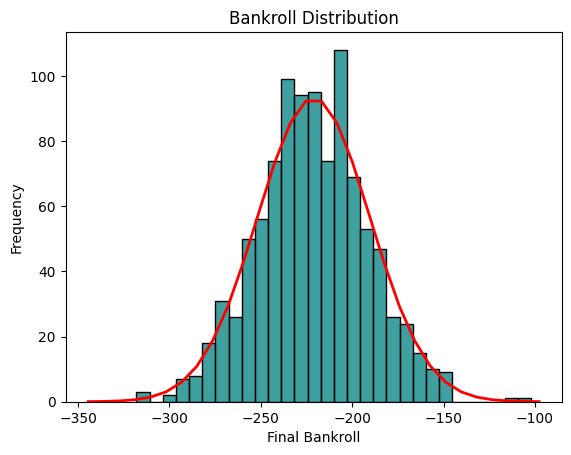

In [ ]:
p_roulette = get_roulette_pwheel(slot_dist1)
roulette_results = np.random.choice([0, 1, 2], size=(N_PLAYERS, N_GAMES), p=p_roulette)
player_choices = np.random.choice([0, 1, 2], size=(N_PLAYERS, N_GAMES), p=player_choice_p)
inst_pnl = np.where(roulette_results == player_choices, 1, -1)

bankroll = inst_pnl.sum(axis=1)

bernoulli_p = np.sum(player_choice_p * p_roulette)
mu = N_GAMES * (2 * bernoulli_p - 1)
print(mu)
sigma = 2*np.sqrt(N_GAMES * bernoulli_p * (1 -  bernoulli_p))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 30)
y = stats.norm.pdf(x, mu, sigma) * N_PLAYERS

hist_ax = sns.histplot(bankroll, color="teal", bins=30)
bin_width = hist_ax.patches[0].get_width()
plt.plot(x, y * bin_width, color='red', lw=2, label=f'Normal ($mu={mu:.2f}, sigma={sigma:.2f}$)')
plt.title("Bankroll Distribution")
plt.xlabel("Final Bankroll")
plt.ylabel("Frequency")

plt.show()

## Part B: Quality Control

In [ ]:
mu = 1000
var = 25

In [ ]:
population = np.random.normal(mu, np.sqrt(var), 100_000)

In [ ]:
n = 60
k = 10000

samples = np.random.choice(population, size=n*k)
subsets = samples.reshape((k, n))

uSV = np.apply_along_axis(lambda x: np.var(x, ddof=1), 1, subsets)
chiSqY = uSV * (n - 1) / var

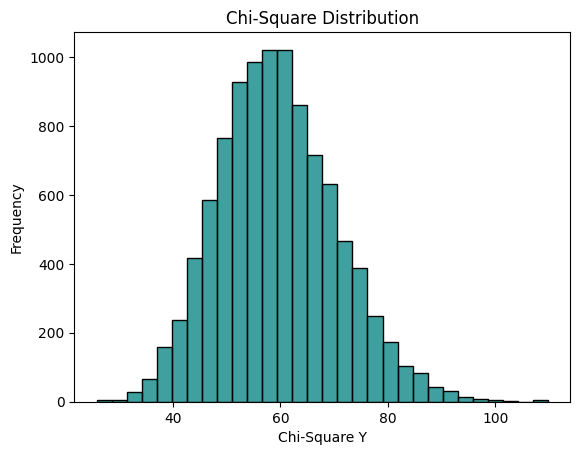

In [ ]:
sns.histplot(chiSqY, color="teal", bins=30)
plt.title("Chi-Square Distribution")
plt.xlabel("Chi-Square Y")
plt.ylabel("Frequency")
plt.show()

## In Class Assignment

#### Part 1

In [ ]:
interact(
    lambda r, b: simulate_roulette([r, b, 1-(r+b)], np.array([18, 16, 2])),
    r=widgets.FloatSlider(
        value=0.4,
        min=0,
        max=1.0,
        step=0.01,
        description='P(r):',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.2f',
    ),
    b=widgets.FloatSlider(
        value=0.4,
        min=0,
        max=1.0,
        step=0.01,
        description='P(b):',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.2f',
    ),
)

interactive(children=(FloatSlider(value=0.4, continuous_update=False, description='P(r):', max=1.0, step=0.01)…

<function __main__.<lambda>(r, b)>

Mean: 0.0 
Std 100.0


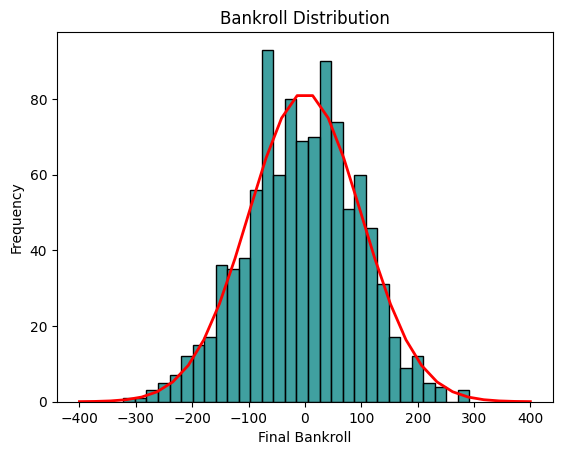

In [ ]:
r, b = 1.0, 0
player_choice_p = [r, b, 1 - r - b]
slot_dist = [18, 16, 2]

(N_PLAYERS, N_GAMES) = 1000, 10_000

p_roulette = get_roulette_pwheel(slot_dist)
roulette_results = np.random.choice([0, 1, 2], size=(N_PLAYERS, N_GAMES), p=p_roulette)
player_choices = np.random.choice([0, 1, 2], size=(N_PLAYERS, N_GAMES), p=player_choice_p)
inst_pnl = np.where(roulette_results == player_choices, 1, -1)

bankroll = inst_pnl.sum(axis=1)

bernoulli_p = np.sum(player_choice_p * p_roulette)
mu = N_GAMES * (2 * bernoulli_p - 1)
sigma = 2*np.sqrt(N_GAMES * bernoulli_p * (1 -  bernoulli_p))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 30)
print("Mean:", mu, "\nStd", sigma)
y = stats.norm.pdf(x, mu, sigma) * N_PLAYERS

hist_ax = sns.histplot(bankroll, color="teal", bins=30)
bin_width = hist_ax.patches[0].get_width()
plt.plot(x, y * bin_width, color='red', lw=2, label=f'Normal ($mu={mu:.2f}, sigma={sigma:.2f}$)')
plt.title("Bankroll Distribution")
plt.xlabel("Final Bankroll")
plt.ylabel("Frequency")

plt.show()

#### Part 2

In [ ]:
mu = 1000
var = 25

population = np.random.normal(mu, np.sqrt(var), 100_000)

n = 30
k = 10000

samples = np.random.choice(population, size=n*k)
subsets = samples.reshape((k, n))

newF = np.apply_along_axis(lambda x: (np.sum((x - mu)**2)), 1, subsets)
Z = newF / var

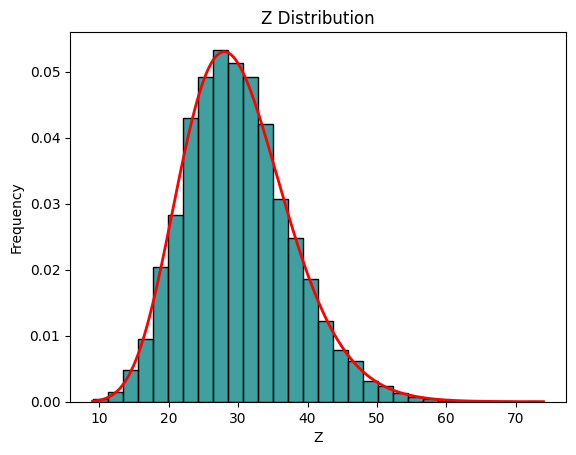

In [ ]:
sns.histplot(Z, color="teal", bins=30,stat="density")
x = np.linspace(Z.min(), Z.max(), 500)
pdf = stats.chi2.pdf(x, df=n)
plt.plot(x, pdf, color="red", lw=2, label=f"Theoretical chi^2 (df={n})")
plt.title("Z Distribution")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.show()